# Radar
Please read the `README.md` file before running this tutorial.

This tutorial shows some basic radar data accessing and helper functions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from pyboreas import BoreasDataset
from pyboreas.utils.utils import get_inverse_tf
from scipy.ndimage import shift
from pyboreas.utils.odometry import interpolate_poses 

root = '/path/to/data/boreas/'
split = None
# AWS: Note: Free Tier SageMaker instances don't have enough storage (25 GB) for 1 sequence (100 GB)
# root = '/home/ec2-user/SageMaker/boreas/'
# split = [['boreas-2021-09-02-11-42', 163059759e6, 163059760e6-1]]

# With verbose=True, the following will print information about each sequence
bd = BoreasDataset(root, split=split, verbose=True)
# Grab the first sequence
seq = bd.sequences[0]

In [ ]:
for i in range(len(seq.radar_frames)):
    if seq.radar_frames[i].frame == '1733248500546068':
        print(i)
        break

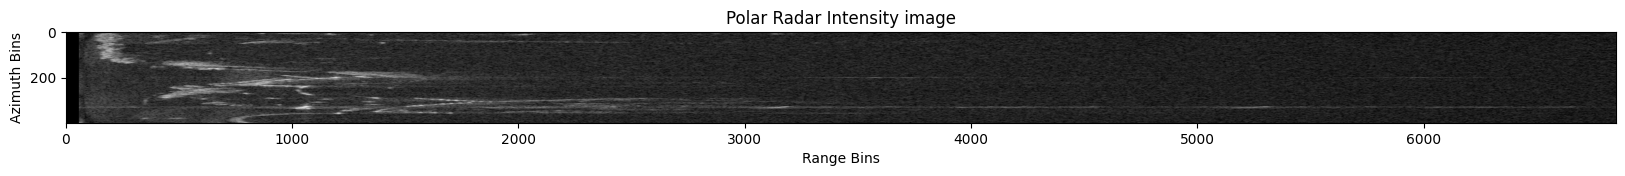

In [29]:
# The raw radar data is contained within a polar image.
# Note that the first 2.5 meters of the radar image are zeroed out by default
# to remove noise from the vehicle itself.

rad = seq.get_radar(i)
plt.figure(figsize=(20, 100))
polar_img = plt.imshow(rad.polar, cmap="gray")
plt.title("Polar Radar Intensity image")
plt.xlabel("Range Bins")
plt.ylabel("Azimuth Bins")
plt.show()

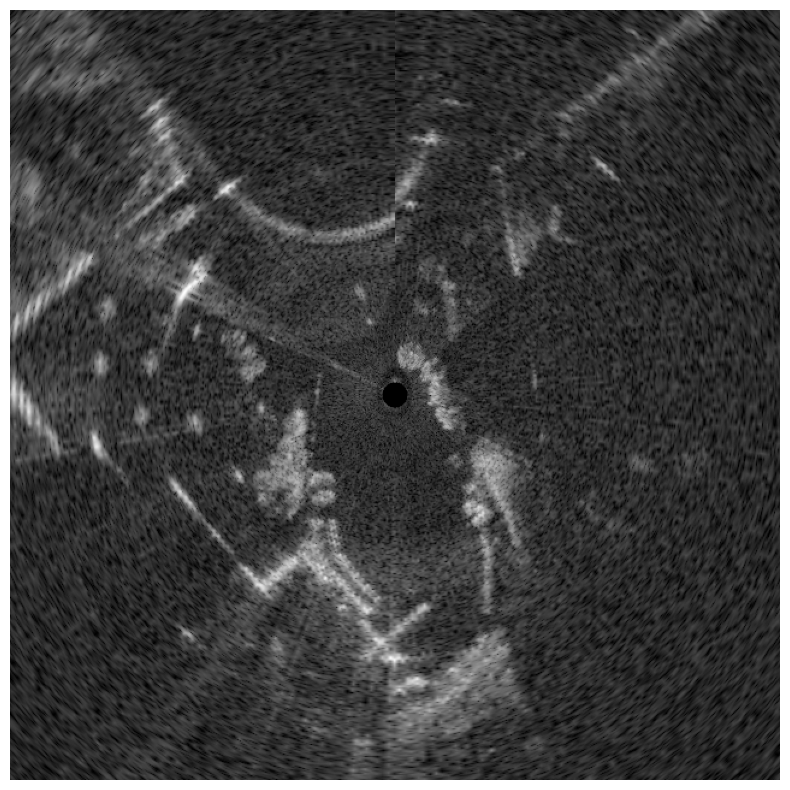

<Axes: >

In [30]:
# Below we present the raw distorted cartesian image

rad.visualize()

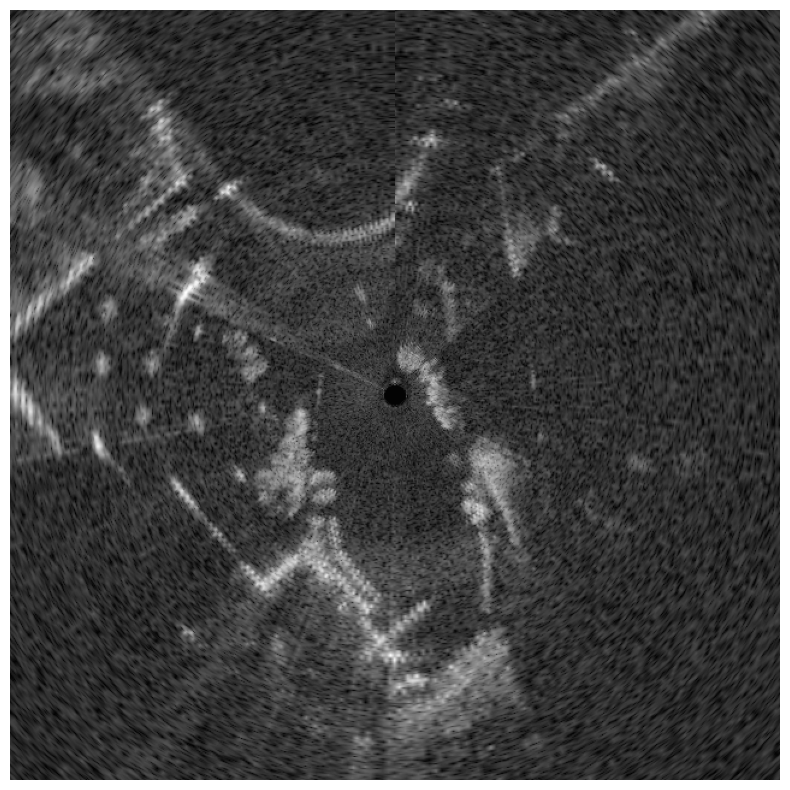

<Axes: >

In [31]:
# First correct each azimuth of polar image for radar offset and Doppler Distortion

# Constant correction offset
shifted_polar = shift(rad.polar, shift=(0, seq.calib.radar_offset / rad.resolution), order=3, mode='nearest')

# Doppler distortion correction
vx = rad.body_rate[0]
vy = rad.body_rate[1]
u = vx * np.cos(rad.azimuths) + vy * np.sin(rad.azimuths)
beta = seq.calib.radar_doppler_beta
delta_r_d = beta * u
chirp_sign = np.where(rad.chirp_type == 0, -1, rad.chirp_type)
doppler_shift = chirp_sign * delta_r_d / rad.resolution # need to SUBTRACT this to get real range

for idx in range(rad.polar.shape[0]):
    shifted_polar[idx] = shift(
        shifted_polar[idx],
        shift=-doppler_shift[idx], # negative to undistort
        order=3,
        mode='nearest'
    )

rad.polar = shifted_polar
rad.visualize()

In [ ]:
# To correct for motion distortion, use interpolate_poses to get the radar pose for each azimuth

poses = [seq.radar_frames[i - 1].pose, seq.radar_frames[i].pose, seq.radar_frames[i + 1].pose] # poses are T_enu_radar
times = [seq.radar_frames[i - 1].timestamp_micro, seq.radar_frames[i].timestamp_micro, seq.radar_frames[i + 1].timestamp_micro]
query_times = rad.timestamps.flatten().tolist()
query_poses = interpolate_poses(poses, times, query_times)

cart = rad.undistort_motion(
    query_poses, 
    cart_resolution = 0.2384,
    cart_pixel_width = 640, 
    azimuth_upsample = 3
    )

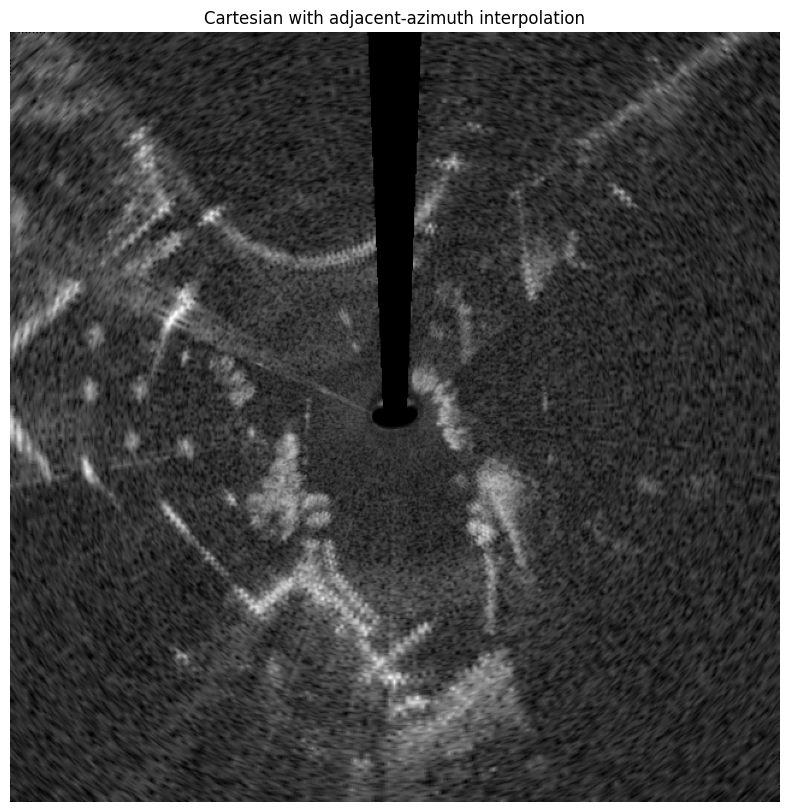

In [ ]:
# The corrected cartesian image is below. Note that the black region is due to rotation
# of the vehicle during the radar frame scan

plt.figure(figsize=(10,10))
plt.imshow(cart, cmap="gray")
plt.title("Cartesian with adjacent-azimuth interpolation")
plt.axis("off")
plt.show()

In [27]:
rad.unload_data()